In [1]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from torchvision import transforms
import torchvision.transforms.functional as TF
from multiprocessing import pool
from functools import partial
%matplotlib inline

In [2]:
def squareImage(image, size):
    image = image.resize((size,size), Image.ANTIALIAS)
    transform = []
    transform.append(transforms.RandomHorizontalFlip(p=0.5))
    transform.append(transforms.RandomVerticalFlip(p=0.5))
    transform.append(transforms.ColorJitter(0.5, 0.3, 0.3))
    transform.append(transforms.RandomCrop((size,size), pad_if_needed=True))
    transform.append(transforms.RandomAffine(0, translate=None, scale=(1.0,1.25)))
    transform = transforms.Compose(transform)
    image = transform(image)
    return image

def rectangleImage(image, size):
    height, width = image.size
    if height > width:
        aspect = width / height
        new_height = int(size)
        new_width = int(np.rint(aspect * size))
    else:
        aspect = height / width
        new_height = int(np.rint(aspect * size))
        new_width = int(size)
    image = image.resize((new_height, new_width), Image.ANTIALIAS)
    transform = []
    transform.append(transforms.RandomHorizontalFlip(p=0.5))
    transform.append(transforms.RandomVerticalFlip(p=0.5))
    transform.append(transforms.ColorJitter(0.5, 0.3, 0.3))
    transform.append(transforms.RandomCrop((size,size), pad_if_needed=True))
    transform.append(transforms.RandomAffine(0, translate=None, scale=(1.0,1.25)))
    transform = transforms.Compose(transform)
    image = transform(image)
    return image

In [3]:
def plot_image(source, name, size):
    f, axarr = plt.subplots(1,2)
    image = Image.open('../../data/{}/train/'.format(source) + name + '.jpg')
    axarr[0].imshow(image)
    height, width = image.size
    if abs(height - width) < 20:
        image = squareImage(image, size)
    else:
        image = rectangleImage(image, size)
    axarr[1].imshow(image)
    return None

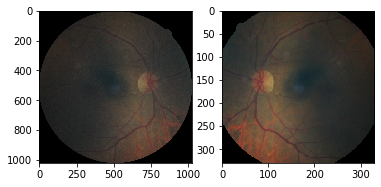

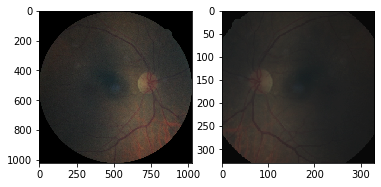

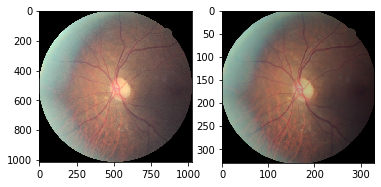

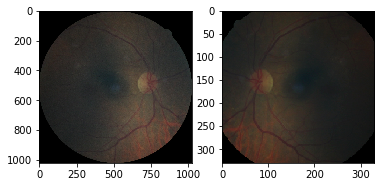

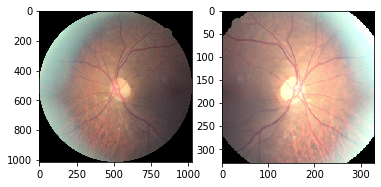

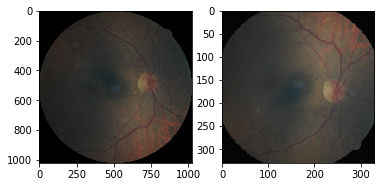

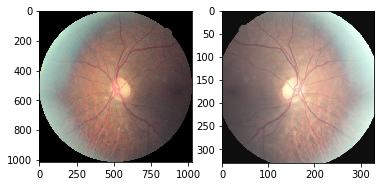

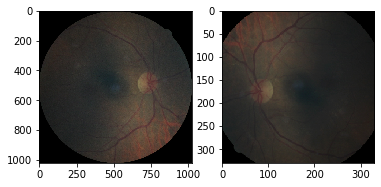

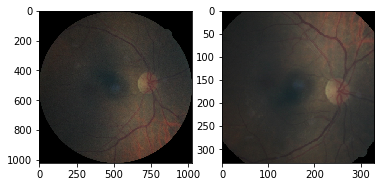

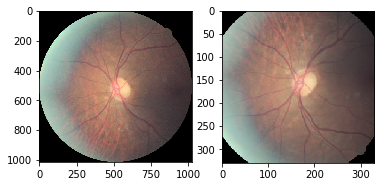

In [4]:
data = pd.read_csv('../../data/pretrain/train_folds.csv')
for _ in range(10):
    idx = np.random.choice(range(2))
    plot_image('pretrain', data.iloc[idx,0], 330)

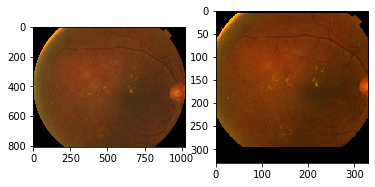

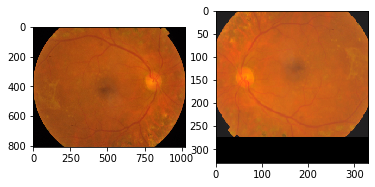

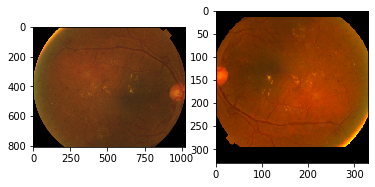

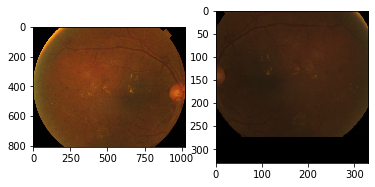

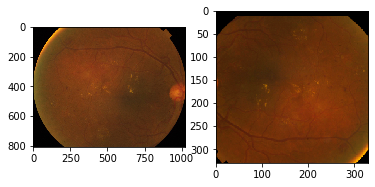

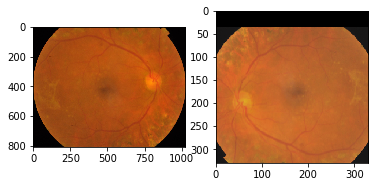

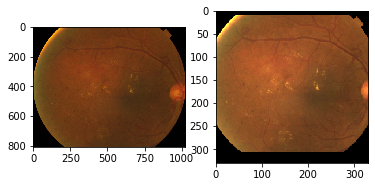

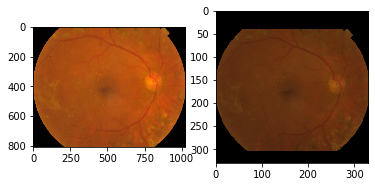

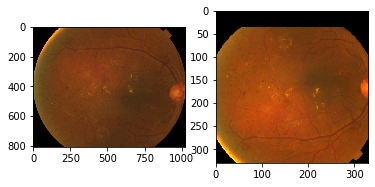

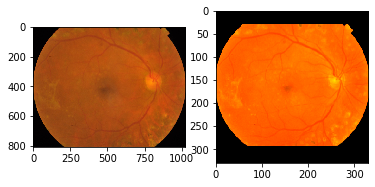

In [5]:
data = pd.read_csv('../../data/train/train_folds.csv')
for _ in range(10):
    idx = np.random.choice(range(2))
    plot_image('train', data.iloc[idx,0], 330)